In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Path to raw data
DATA_DIR = Path('../data/raw')

print('All imports successful ✅')

All imports successful ✅


In [2]:
customers   = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
orders      = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
payments    = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
products    = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
sellers     = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
geo         = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

datasets = {
    'customers':   customers,
    'orders':      orders,
    'order_items': order_items,
    'payments':    payments,
    'reviews':     reviews,
    'products':    products,
    'sellers':     sellers,
    'geo':         geo,
}

print('All datasets loaded ✅\n')
for name, df in datasets.items():
    print(f'{name:<15} → {df.shape[0]:>7,} rows  |  {df.shape[1]:>2} columns')

All datasets loaded ✅

customers       →  99,441 rows  |   5 columns
orders          →  99,441 rows  |   8 columns
order_items     → 112,650 rows  |   7 columns
payments        → 103,886 rows  |   5 columns
reviews         →  99,224 rows  |   7 columns
products        →  32,951 rows  |   9 columns
sellers         →   3,095 rows  |   4 columns
geo             → 1,000,163 rows  |   5 columns


In [3]:
# Quick peek at each table
for name, df in datasets.items():
    print(f'\n {name.upper()} ')
    display(df.head(2))


 CUSTOMERS 


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP



 ORDERS 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00



 ORDER_ITEMS 


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00



 SELLERS 


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP



 GEO 


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP


In [4]:
print(' NULL VALUES PER DATASET ')
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\n{name}:')
        for col, count in nulls.items():
            pct = (count / len(df)) * 100
            print(f'  {col:<45} {count:>6,} nulls  ({pct:.1f}%)')
    else:
        print(f'\n{name}: ✅ No nulls')

 NULL VALUES PER DATASET 

customers: ✅ No nulls

orders:
  order_approved_at                                160 nulls  (0.2%)
  order_delivered_carrier_date                   1,783 nulls  (1.8%)
  order_delivered_customer_date                  2,965 nulls  (3.0%)

order_items: ✅ No nulls

payments: ✅ No nulls

reviews:
  review_comment_title                          87,656 nulls  (88.3%)
  review_comment_message                        58,247 nulls  (58.7%)

products:
  product_category_name                            610 nulls  (1.9%)
  product_name_lenght                              610 nulls  (1.9%)
  product_description_lenght                       610 nulls  (1.9%)
  product_photos_qty                               610 nulls  (1.9%)
  product_weight_g                                   2 nulls  (0.0%)
  product_length_cm                                  2 nulls  (0.0%)
  product_height_cm                                  2 nulls  (0.0%)
  product_width_cm                          

In [5]:
print(' DUPLICATE ROWS ')
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    status = '✅' if dupes == 0 else '⚠️'
    print(f'{status} {name:<15}: {dupes:,} duplicates')

 DUPLICATE ROWS 
✅ customers      : 0 duplicates
✅ orders         : 0 duplicates
✅ order_items    : 0 duplicates
✅ payments       : 0 duplicates
✅ reviews        : 0 duplicates
✅ products       : 0 duplicates
✅ sellers        : 0 duplicates
⚠️ geo            : 261,831 duplicates


In [6]:
print(f'Total unique products: {products["product_id"].nunique():,}')
print(f'Total categories: {products["product_category_name"].nunique()}')
print()
print(products.dtypes)

Total unique products: 32,951
Total categories: 73

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


In [7]:
# Translate category names to English
products = products.merge(category_translation, on='product_category_name', how='left')
products['category_en'] = products['product_category_name_english'].fillna(products['product_category_name'])

print('Category translation applied ✅')
products[['product_id', 'product_category_name', 'category_en']].head(5)

Category translation applied ✅


,product_id,product_category_name,category_en
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [8]:
# Top 20 product categories
top_categories = products['category_en'].value_counts().head(20)

print(f'\nTop 20 categories:')
print(top_categories.head(20))


Top 20 categories:
category_en
bed_bath_table                     3029
sports_leisure                     2867
furniture_decor                    2657
health_beauty                      2444
housewares                         2335
auto                               1900
computers_accessories              1639
toys                               1411
watches_gifts                      1329
telephony                          1134
baby                                919
perfumery                           868
stationery                          849
fashion_bags_accessories            849
cool_stuff                          789
garden_tools                        753
pet_shop                            719
electronics                         517
construction_tools_construction     400
home_appliances                     370
Name: count, dtype: int64


Products missing description length: 610
Products missing name length:        610



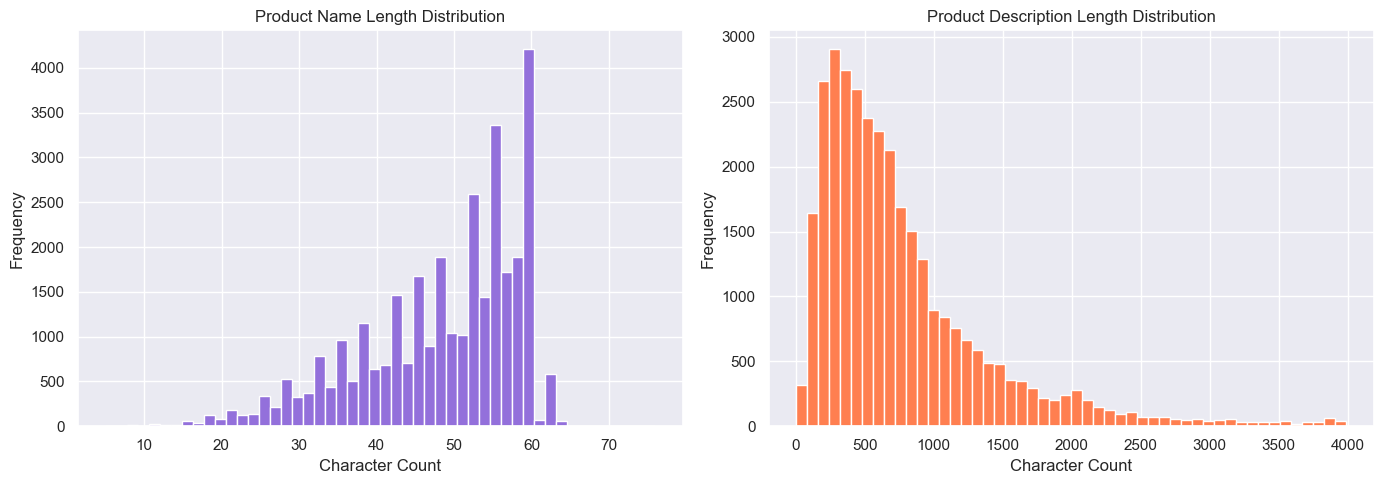

In [9]:
# Product description quality — key for embeddings
desc_nulls = products['product_description_lenght'].isnull().sum()
name_nulls = products['product_name_lenght'].isnull().sum()

print(f'Products missing description length: {desc_nulls:,}')
print(f'Products missing name length:        {name_nulls:,}')
print()

# Distribution of description lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

products['product_name_lenght'].dropna().plot(
    kind='hist', bins=50, ax=axes[0], color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Product Name Length Distribution')
axes[0].set_xlabel('Character Count')

products['product_description_lenght'].dropna().plot(
    kind='hist', bins=50, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Product Description Length Distribution')
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.show()

In [10]:
physical_cols = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

print("-"*30)
print("Summary")
print("-"*30)

for col in physical_cols:
    data = products[col].dropna()
    
    print(f"\n{col}")
    print()
    print(f"Count            : {data.count():,}")
    print(f"Mean             : {data.mean():.2f}")
    print(f"Median           : {data.median():.2f}")
    print(f"Std Dev          : {data.std():.2f}")
    print(f"Min              : {data.min():.2f}")
    print(f"Max              : {data.max():.2f}")
    print(f"99th Percentile  : {data.quantile(0.99):.2f}")


------------------------------
Summary
------------------------------

product_weight_g

Count            : 32,949
Mean             : 2276.47
Median           : 700.00
Std Dev          : 4282.04
Min              : 0.00
Max              : 40425.00
99th Percentile  : 22538.00

product_length_cm

Count            : 32,949
Mean             : 30.82
Median           : 25.00
Std Dev          : 16.91
Min              : 7.00
Max              : 105.00
99th Percentile  : 100.00

product_height_cm

Count            : 32,949
Mean             : 16.94
Median           : 13.00
Std Dev          : 13.64
Min              : 2.00
Max              : 105.00
99th Percentile  : 69.00

product_width_cm

Count            : 32,949
Mean             : 23.20
Median           : 20.00
Std Dev          : 12.08
Min              : 6.00
Max              : 118.00
99th Percentile  : 63.00


In [11]:
print(f'Total orders: {orders["order_id"].nunique():,}')
print(f'Total customers: {orders["customer_id"].nunique():,}')
print()
print('Order status breakdown:')
print(orders['order_status'].value_counts())

Total orders: 99,441
Total customers: 99,441

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


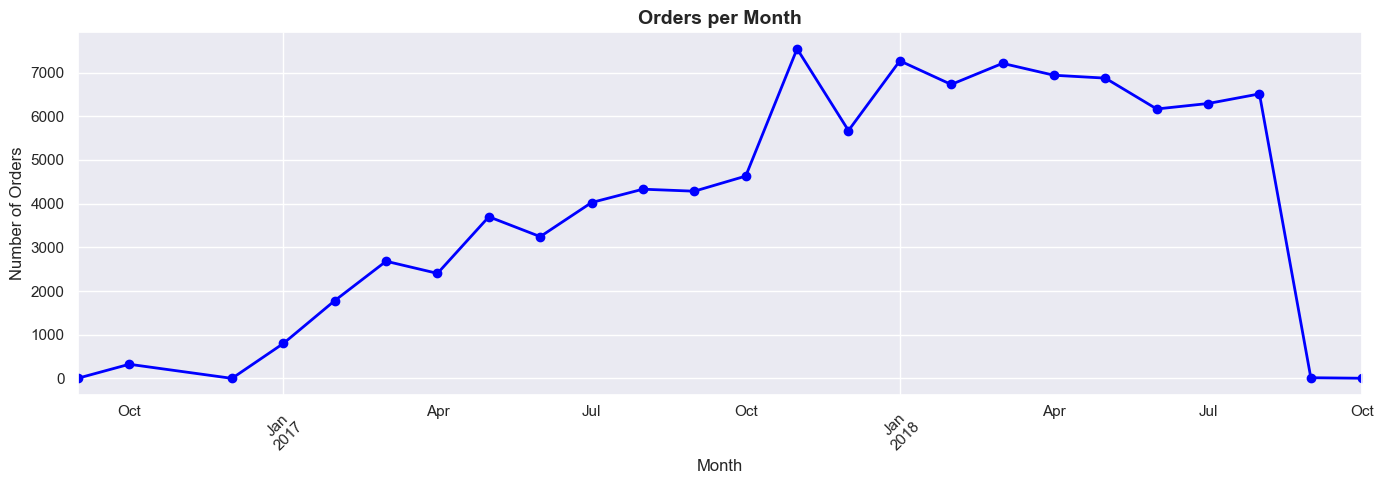

In [12]:
# Parse timestamps
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Orders over time
monthly_orders = orders.groupby('order_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_orders.plot(kind='line', ax=ax, marker='o', color='blue', linewidth=2)
ax.set_title('Orders per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Items per order
items_per_order = order_items.groupby('order_id')['order_item_id'].max()

print('Items per order:')
print(items_per_order.value_counts().sort_index())

Items per order:
order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64


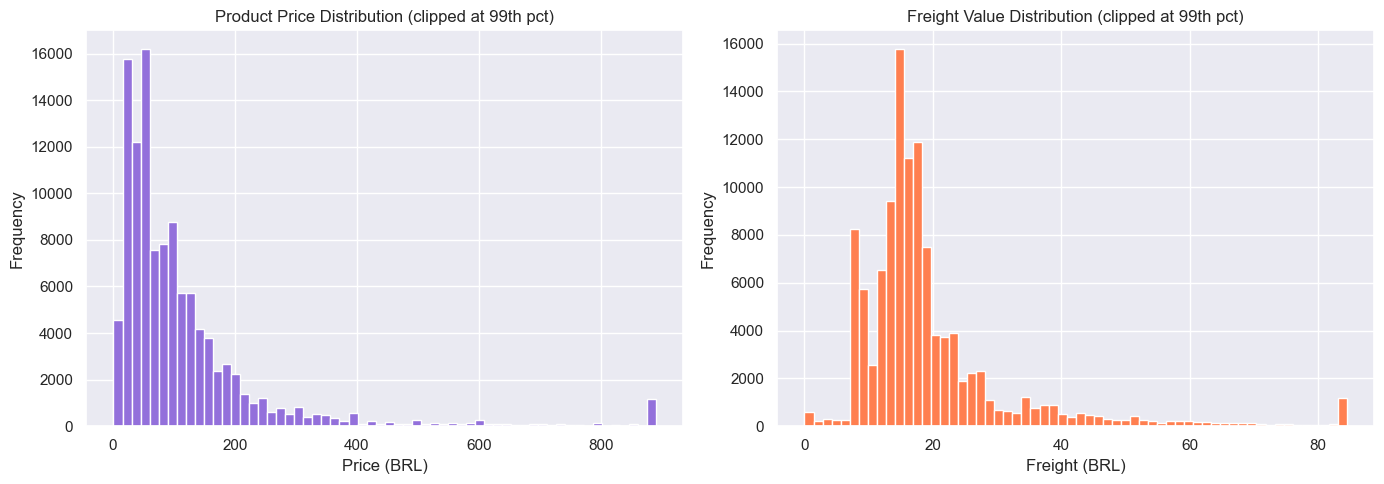

Average product price: $120.65
Median product price:  $74.99
Max product price:     $6735.00


In [14]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_items['price'].clip(upper=order_items['price'].quantile(0.99)).plot(
    kind='hist', bins=60, ax=axes[0], color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Product Price Distribution (clipped at 99th pct)')
axes[0].set_xlabel('Price (BRL)')

order_items['freight_value'].clip(upper=order_items['freight_value'].quantile(0.99)).plot(
    kind='hist', bins=60, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Freight Value Distribution (clipped at 99th pct)')
axes[1].set_xlabel('Freight (BRL)')

plt.tight_layout()
plt.show()

print(f'Average product price: ${order_items["price"].mean():.2f}')
print(f'Median product price:  ${order_items["price"].median():.2f}')
print(f'Max product price:     ${order_items["price"].max():.2f}')

In [15]:
print(f'Total reviews: {reviews["review_id"].nunique():,}')
print(f'Reviews with comment text: {reviews["review_comment_message"].notna().sum():,}')
print()

score_counts = reviews['review_score'].value_counts().sort_index()

print("Review Score Distribution:")
for score, count in score_counts.items():
    percentage = (count / len(reviews)) * 100
    print(f"{score} star: {count:,} ({percentage:.2f}%)")

print()
print(f'Average review score: {reviews["review_score"].mean():.2f}')

Total reviews: 98,410
Reviews with comment text: 40,977

Review Score Distribution:
1 star: 11,424 (11.51%)
2 star: 3,151 (3.18%)
3 star: 8,179 (8.24%)
4 star: 19,142 (19.29%)
5 star: 57,328 (57.78%)

Average review score: 4.09


In [16]:
reviews_with_products = reviews.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
reviews_with_products = reviews_with_products.merge(
    order_items[['order_id', 'product_id']], on='order_id', how='left'
)

reviews_per_product = reviews_with_products.groupby('product_id')['review_score'].agg(['count', 'mean'])
reviews_per_product.columns = ['review_count', 'avg_score']

print(f'Products with at least 1 review: {(reviews_per_product["review_count"] >= 1).sum():,}')
print(f'Products with 0 reviews (cold-start products): {products["product_id"].nunique() - len(reviews_per_product):,}')
print()
print('Review count per product stats:')
print(reviews_per_product['review_count'].describe())

Products with at least 1 review: 32,789
Products with 0 reviews (cold-start products): 162

Review count per product stats:
count   32789.00
mean        3.43
std        10.63
min         1.00
25%         1.00
50%         1.00
75%         3.00
max       524.00
Name: review_count, dtype: float64


In [17]:
orders_per_customer = orders.groupby('customer_id')['order_id'].count()

print('Orders per customer:')
print(orders_per_customer.value_counts().head(10))
print()
print(f'Customers with only 1 order: {(orders_per_customer == 1).sum():,} ({(orders_per_customer == 1).mean()*100:.1f}%)')
print(f'Customers with 2+ orders:    {(orders_per_customer >= 2).sum():,} ({(orders_per_customer >= 2).mean()*100:.1f}%)')

Orders per customer:
order_id
1    99441
Name: count, dtype: int64

Customers with only 1 order: 99,441 (100.0%)
Customers with 2+ orders:    0 (0.0%)


In [18]:
one_order_pct = (orders_per_customer == 1).mean() * 100

print('=' * 55)
print(f'  {one_order_pct:.1f}% of customers have placed only ONE order.')
print(f'  This confirms the cold-start problem is real and severe.')
print(f'  Traditional collaborative filtering would fail for them.')
print(f'  This is exactly the problem NOVA is designed to solve.')
print('=' * 55)

  100.0% of customers have placed only ONE order.
  This confirms the cold-start problem is real and severe.
  Traditional collaborative filtering would fail for them.
  This is exactly the problem NOVA is designed to solve.


In [19]:
product_stats = order_items.groupby('product_id').agg(
    times_purchased=('order_id', 'count'),
    avg_price=('price', 'mean'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
).reset_index()

product_features = products.merge(product_stats, on='product_id', how='left')
product_features = product_features.merge(
    reviews_per_product.reset_index(), on='product_id', how='left'
)

product_features['times_purchased'] = product_features['times_purchased'].fillna(0)
product_features['review_count'] = product_features['review_count'].fillna(0)

print(f'Product feature table shape: {product_features.shape}')
print()
product_features.head(3)

Product feature table shape: (32951, 17)



,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_en,times_purchased,avg_price,min_price,max_price,review_count,avg_score
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery,perfumery,1,10.91,10.91,10.91,1.00,5.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art,art,1,248.00,248.00,248.00,1.00,5.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure,sports_leisure,1,79.80,79.80,79.80,1.00,5.00


In [20]:
print('FEATURES AVAILABLE FOR PRODUCT EMBEDDINGS:')
print()
print('  Text features (for Sentence-Transformers):')
print('    - category_en          (product category in English)')
print()
print('  Numeric features:')
print('    - avg_price            (average sale price)')
print('    - product_weight_g     (weight)')
print('    - product_length_cm    (dimensions)')
print('    - product_height_cm')
print('    - product_width_cm')
print('    - product_photos_qty   (number of product images)')
print()
print('  Behavioral features (for warm-start only):')
print('    - times_purchased      (popularity signal)')
print('    - avg_score            (review score)')
print('    - review_count')
print()
print('  NOTE: Text descriptions are NOT available in Olist.')
print('        Category name is the primary text signal.')
print('        We will enrich this with synthetic descriptions in the next notebook.')

FEATURES AVAILABLE FOR PRODUCT EMBEDDINGS:

  Text features (for Sentence-Transformers):
    - category_en          (product category in English)

  Numeric features:
    - avg_price            (average sale price)
    - product_weight_g     (weight)
    - product_length_cm    (dimensions)
    - product_height_cm
    - product_width_cm
    - product_photos_qty   (number of product images)

  Behavioral features (for warm-start only):
    - times_purchased      (popularity signal)
    - avg_score            (review score)
    - review_count

  NOTE: Text descriptions are NOT available in Olist.
        Category name is the primary text signal.
        We will enrich this with synthetic descriptions in the next notebook.


In [21]:
output_path = Path('../data/processed/product_features.csv')
product_features.to_csv(output_path, index=False)
print(f'Product feature table saved to {output_path} ✅')
print(f'Shape: {product_features.shape}')

Product feature table saved to ../data/processed/product_features.csv ✅
Shape: (32951, 17)


## EDA Summary

Key takeaways from this exploration:

**Dataset scale**
- ~100K orders, ~32K unique products, ~96K reviews across 71 product categories

**Cold-start problem is confirmed**
- The vast majority of customers have placed only a single order — collaborative filtering would fail for almost every user
- This validates the core premise of NOVA

**Product text data is limited**
- Olist does not include product titles or descriptions — only category names and physical dimensions
- Next step: enrich product representations by combining category + price tier + physical attributes into a structured text string for embedding

**Review signal is available but sparse**
- Most products have very few reviews — useful as a warm-start signal but not reliable for cold-start

**Next notebook:** `02_product_embeddings.ipynb`
- Construct a text representation for each product
- Generate embeddings using Sentence-Transformers (`all-MiniLM-L6-v2`)
- Visualize the embedding space with UMAP